# Batch-size sensitivity

How Sven and baselines respond to batch size on the polynomial task. Sven's update rank tracks B.

> Loads the fresh Gram-backend results. Robust to partial data (plots whatever has finished).

In [1]:
import sys, json
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
sys.path.insert(0, '.')
from style import load_results, average_over_seeds, set_style
from analysis_helpers import (add_derived, best_per_method, seed_mean_best, config_runs, seed_band,
                              errorbar_seeds, fmt_pm, epochs_to_target_table, valid, loss_curve, method_order,
                              n_params_of)
from style import DATASET_TITLES, metric_label
from style import clipped_yerr
from pathlib import Path
set_style()
PLOT_DIR = Path('plots_v2/batchsize'); PLOT_DIR.mkdir(parents=True, exist_ok=True)
from style import method_color
def sven_color(m): return method_color(m)   # global optimizer colours (style.METHOD_COLORS)
def sven_lw(m):    return 2.6 if m=='Sven' else 1.6

In [2]:
df = add_derived(load_results('rebuttal_batchsize_polynomial_scan'))

Loaded 2376 runs from ../experiment_results/_cache/rebuttal_batchsize_polynomial_scan.slim.pkl (slim cache)


### Final validation loss vs batch size (best config per optimizer)

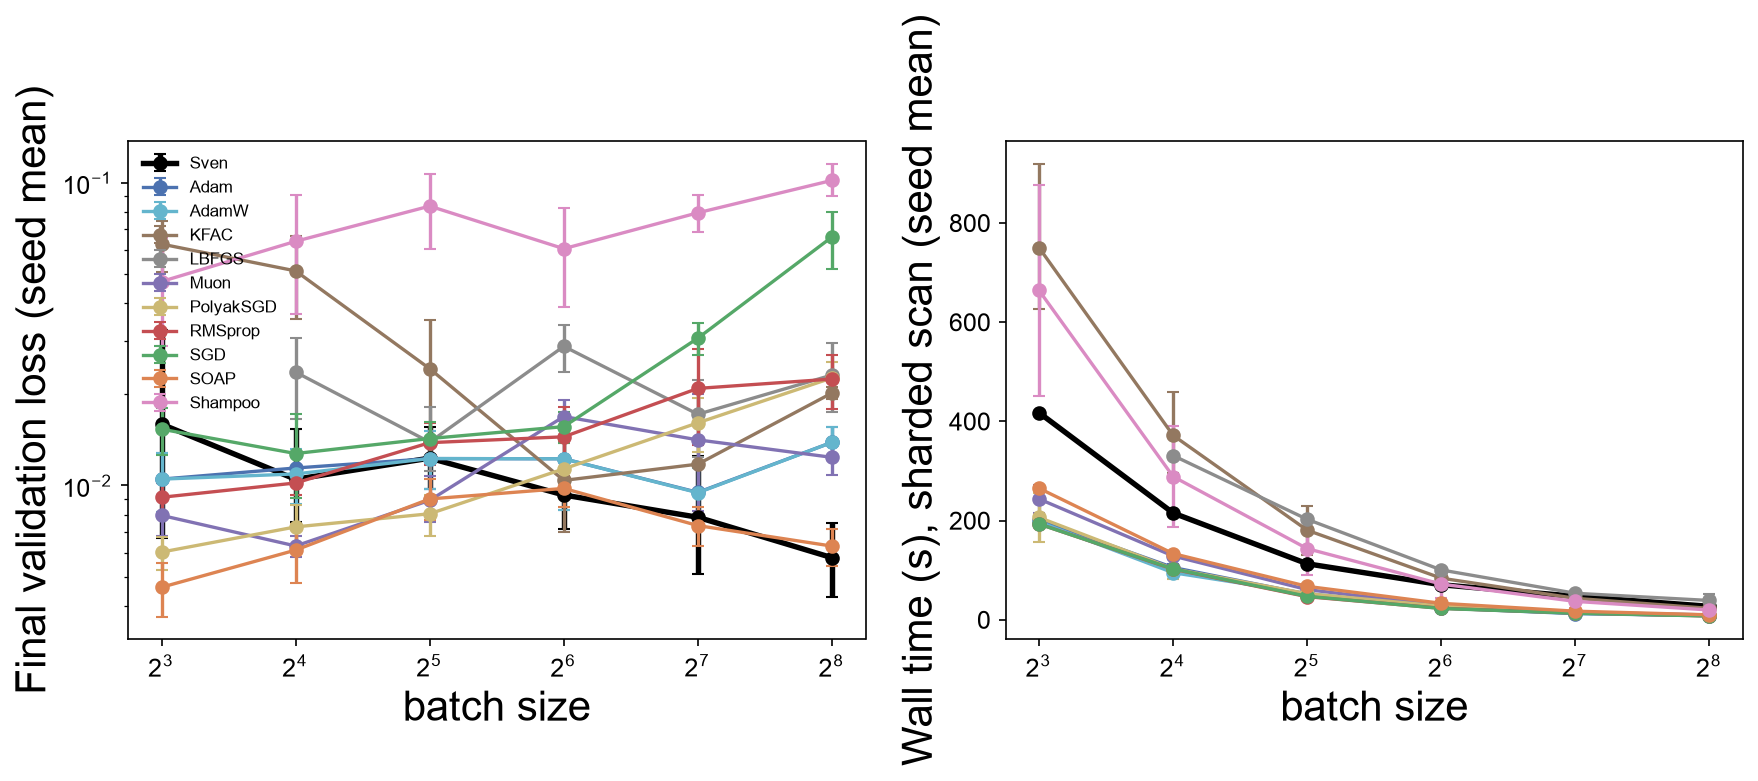

In [3]:
# Best CONFIG per (optimizer, batch size) by seed-mean final VALIDATION loss (the one selection
# metric everywhere); error bars = seed spread.
b=best_per_method(df, by='final_val_loss', extra_group=['batch_size'])
fig,axes=plt.subplots(1,2,figsize=(12,4.4))
for m in method_order(b['method'].unique()):
    s=b[b.method==m]
    errorbar_seeds(axes[0], s, 'batch_size', 'final_val_loss', color=sven_color(m), lw=sven_lw(m), label=m)
    if s['total_time'].notna().any():
        errorbar_seeds(axes[1], s, 'batch_size', 'total_time', color=sven_color(m), lw=sven_lw(m), label=m)
for ax,t in zip(axes,[metric_label('final_val_loss'),'Wall time (s), sharded scan (seed mean)']):
    ax.set_xscale('log',base=2); ax.set_xlabel('batch size'); ax.set_ylabel(t)
axes[0].set_yscale('log'); axes[0].legend(fontsize=8)
plt.tight_layout(); plt.savefig(PLOT_DIR/'vs_batchsize.pdf',bbox_inches='tight'); plt.show()